# Data Preprocessing

# Import Libraries

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings("ignore")

In [20]:
dataset = pd.read_csv('Telecom Customer Churn Dataset.csv')
df = dataset.copy()

# Display the frist few rows of the dataset
print("First 5 rows of the dataset: \n")
print("\n", df.head())

# Display the basic information of dataset
print("\n Dataset Information: ")
print("\n", df.info())

# Check for missing values
print('\nCount of missing values per column:')
print("\n", df.isna().sum())

# Display the statical information of dataset
print("\n Dataset Statical Information: ")
print("\n", df.describe())

# Encoding categorical data of column ' Churn '

from sklearn.preprocessing import LabelEncoder
ie = LabelEncoder()
df['Churn'] = ie.fit_transform(df['Churn'])
print("\nAfter Encoded categorical data of column \'Churn\' :")
print(df['Churn'])

# Converting the type of totalcharges column
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

First 5 rows of the dataset: 


    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

# Exploratory Data Analysis (EDA)

In [21]:
numeric_cols = df.select_dtypes(include = [np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include = ['object']).columns.tolist()

print('Numeric columns:', '\n', numeric_cols)
print('\nCategorical columns:', '\n', categorical_cols)

Numeric columns: 
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

Categorical columns: 
 ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [22]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

# Impute missing values for numeric columns using mean strategy

In [23]:
from sklearn.impute import SimpleImputer
num_imputer = SimpleImputer(strategy='mean')
df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])

In [24]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Histograms for numeric variables

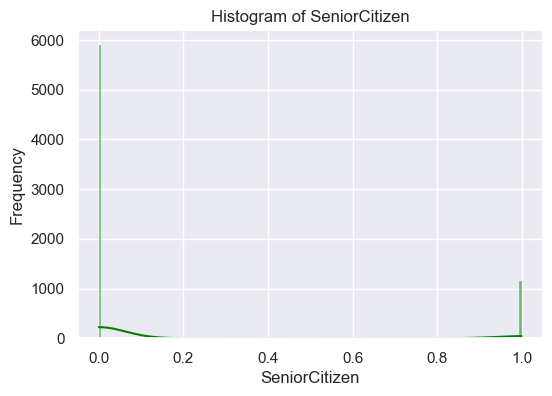

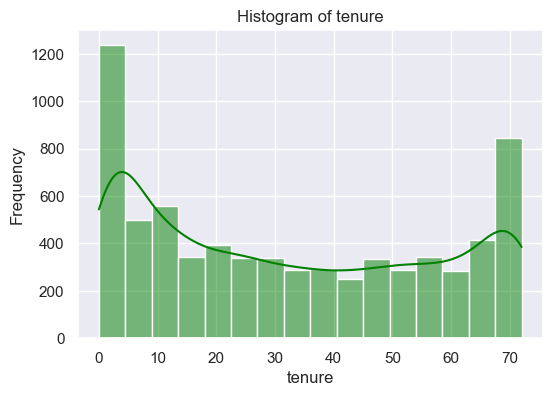

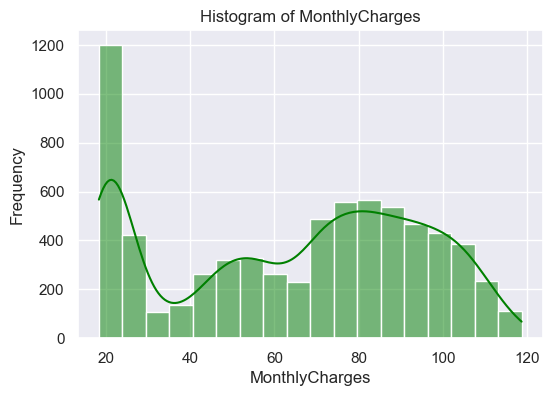

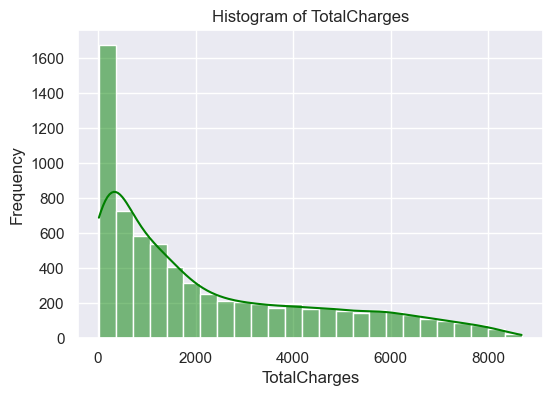

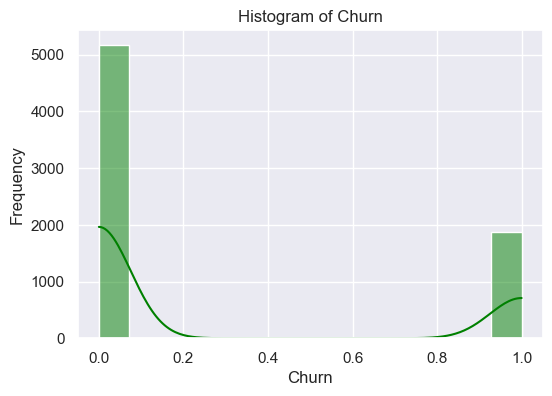

In [25]:
for col in numeric_cols:
    plt.figure(figsize = (6, 4))
    sns.histplot(df[col], kde = True, color = 'green')
    plt.title(f'Histogram of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

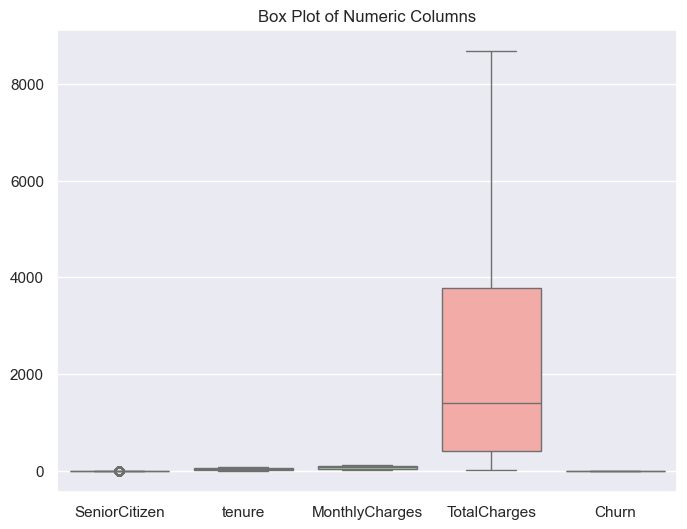

In [26]:
# Boxplot for numeric variables

plt.figure(figsize = (8, 6))
sns.boxplot(df[numeric_cols], palette='pastel')
plt.title('Box Plot of Numeric Columns')
plt.show()

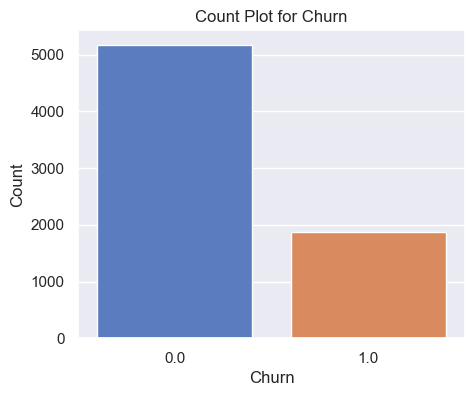

In [27]:
# Count plot ( pie-chart style using count plot) for target variables 'Churn'

if 'Churn' in df.columns:
    plt.figure(figsize = (5, 4))
    sns.countplot(x = 'Churn', data = df, palette = 'muted')
    plt.title('Count Plot for Churn')
    plt.xlabel('Churn')
    plt.ylabel('Count')
    plt.show()

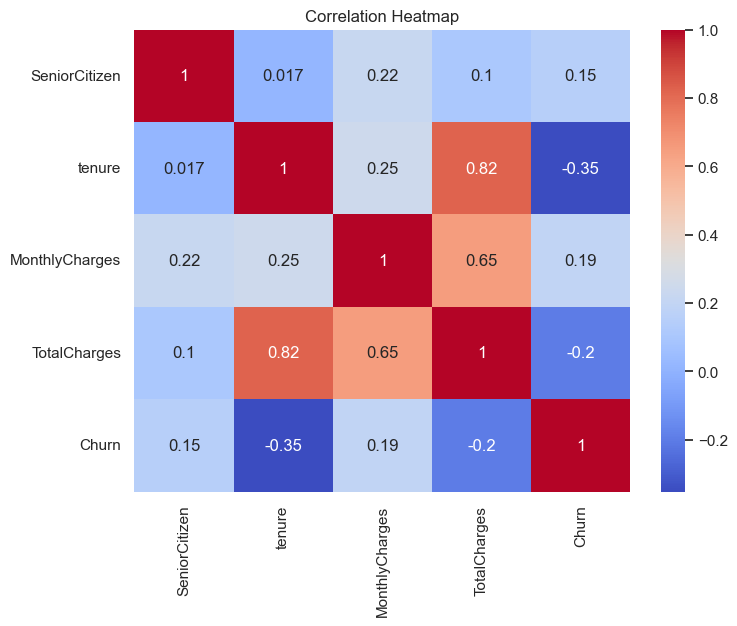

In [28]:
# If there is four or more numeric columns, create a correlation heatmap

numeric_df = df.select_dtypes(include = [np.number])
if numeric_df.shape[1] >=4:
    plt.figure(figsize=(8,6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm')
    plt.title('Correlation Heatmap')
    plt.show()

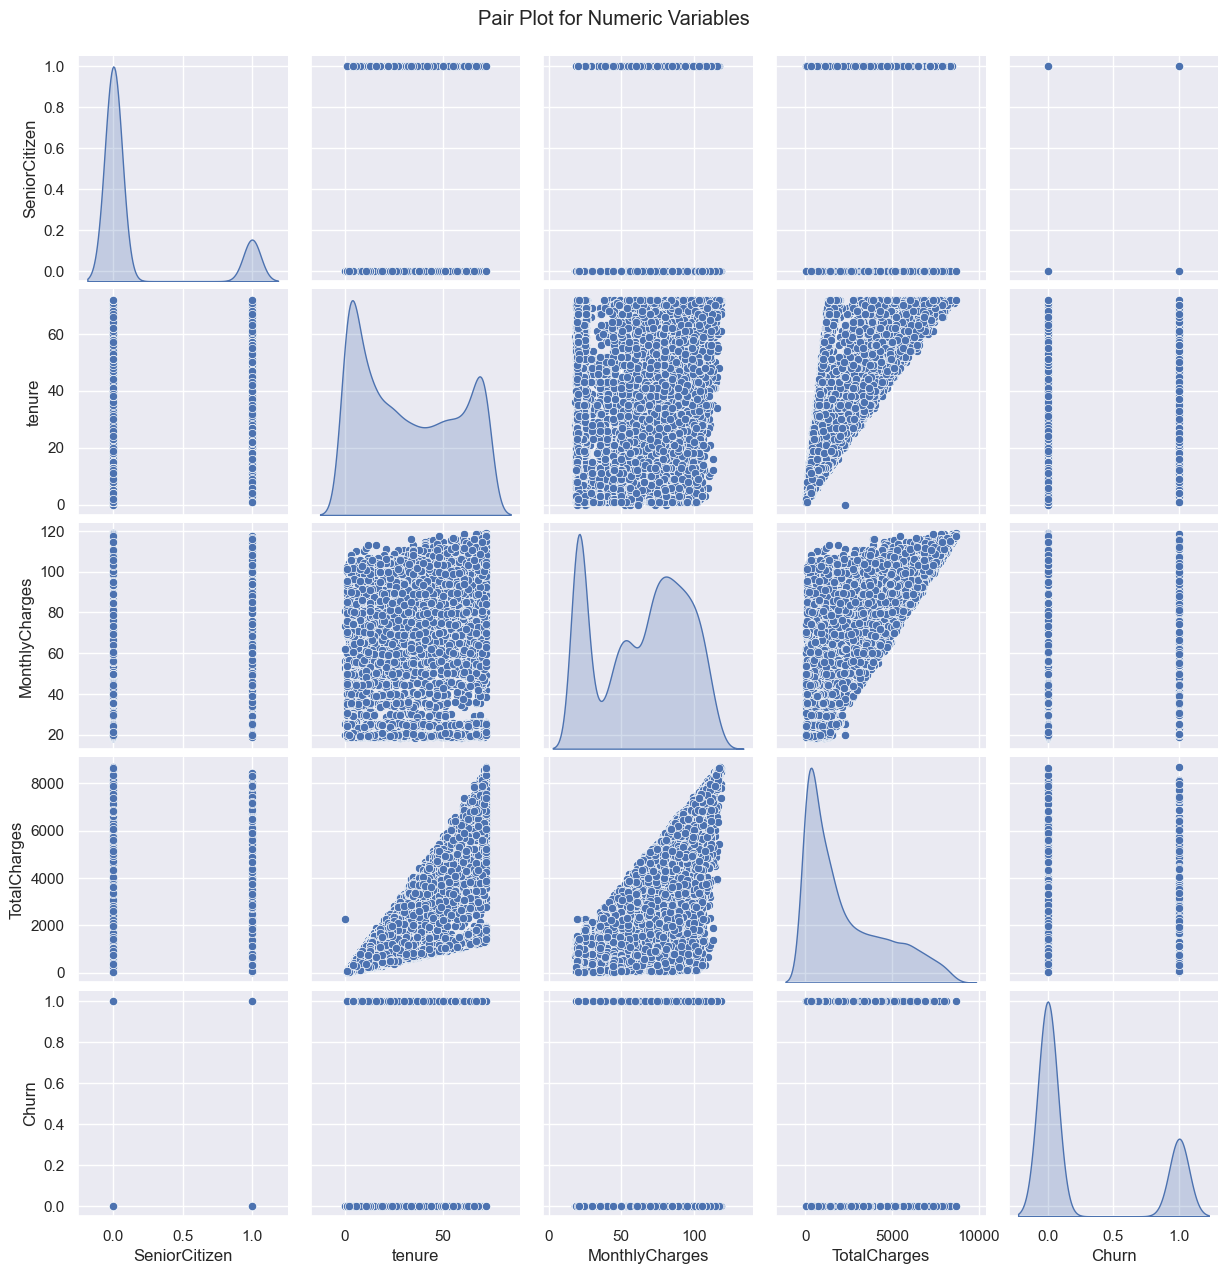

In [29]:
# Pair plot for numeric variables

if numeric_df.shape[1] >= 2:
    sns.pairplot(numeric_df, diag_kind='kde')
    plt.suptitle('Pair Plot for Numeric Variables', y=1.02)
    plt.show()

# Builting Models And Evalueting the models

In [30]:
categorical_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])

# Spliting the dataset into Training set and Test set

In [31]:
x = df.iloc[:, 1:-1].values # here 'df[0]: customerID' column is not inculde due to in model create noise
y = df.iloc[:, -1].values

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

# DecisionTreeClassifier Models


classification_report: 

               precision    recall  f1-score   support

         0.0       0.82      0.82      0.82      1041
         1.0       0.49      0.48      0.48       368

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409


confusion_matrix_report: 
[[855 186]
 [191 177]]


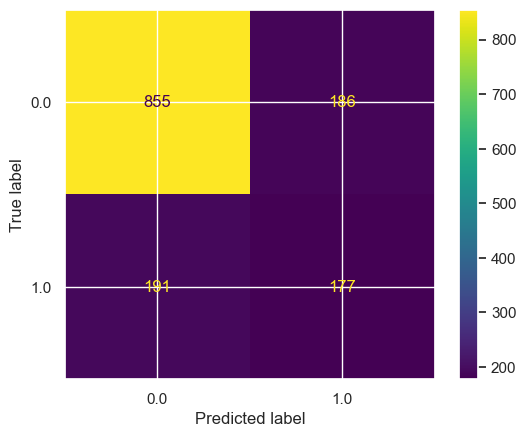


accuracy_score: 

 0.7324343506032647

roc_auc_score: 

 0.6511519546422754

ROC Curve computation and plot: 


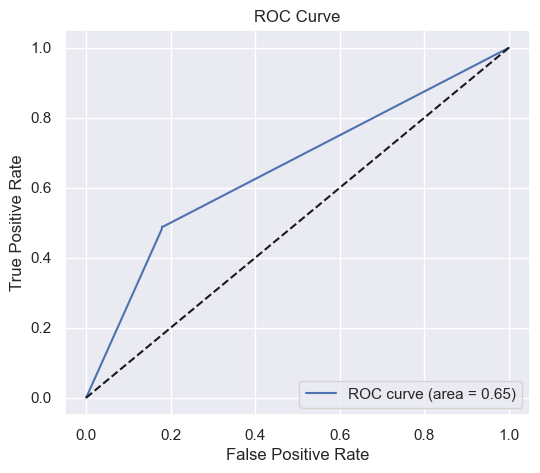


K Fold Cross Validation: 
Mean: 0.7314447047856595
Standard Deviation: 0.016665265979992655


In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import cross_val_score  

classifier = DecisionTreeClassifier(criterion = 'entropy', random_state =0)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

"""classification_report generates a detailed table of precision, recall, F1-score, and support for each class in classification models.
Primary Uses
It evaluates per-class performance (not just overall accuracy), revealing imbalances—e.g., poor recall on minority class in churn prediction.
Ideal alongside confusion matrix for binary/multiclass tasks."""

print("\nclassification_report: ")
print('\n', classification_report(y_test, y_pred))


"""Confusion matrix evaluates classification models by showing actual vs predicted labels in a table format.
Primary Uses
It breaks down predictions into TP (true positive), TN, FP, FN—foundation for metrics like accuracy, precision, recall, F1.
Great for imbalanced data (e.g., churn) to spot class-specific errors beyond simple accuracy."""

print("\nconfusion_matrix_report: ")
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()


"""accuracy_score computes the fraction of correct predictions in classification tasks.
Primary Use
It measures overall correctness: (correct predictions) / (total predictions), ideal for balanced datasets."""

print("\naccuracy_score: ")
print('\n', accuracy_score(y_test, y_pred))

"""roc_auc_score is used for
roc_auc_score computes the Area Under the ROC Curve (AUC) score—a single number summarizing binary classifier performance.
Primary Use
Evaluates how well predicted probabilities rank positive vs negative classes (0.5=random, 1.0=perfect). 
Robust for imbalanced data like churn prediction."""

print("\nroc_auc_score: ")
print('\n', roc_auc_score(y_test, y_pred))


"""ROC-AUC evaluates binary classification models by measuring 
their ability to distinguish between positive and negative classes across all thresholds."""

print("\nROC Curve computation and plot: ")
y_prob = classifier.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds  = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


""" K-Fold Cross Validation assesses model performance reliably by splitting data into K folds, training 
on K-1 and testing on one—repeating K times for averaged, unbiased estimates.
Primary Uses
Prevents overfitting by evaluating on unseen data multiple times.
Maximizes limited data usage (every sample trains/tests).
Provides stable mean/std dev scores to detect under/overfitting.
"""
print("\nK Fold Cross Validation: ")
accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv = 10, n_jobs = -1)
print(f'Mean: {accuracies.mean()}')
print(f'Standard Deviation: {accuracies.std()}')

# RandomForestClassifier Models


classification_report: 

               precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1041
         1.0       0.63      0.48      0.55       368

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409


confusion_matrix_report: 
[[936 105]
 [190 178]]


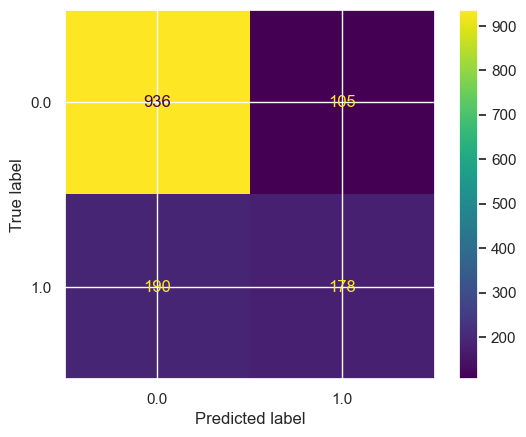


accuracy_score: 

 0.7906316536550745

roc_auc_score: 

 0.691415549429896

ROC Curve computation and plot: 


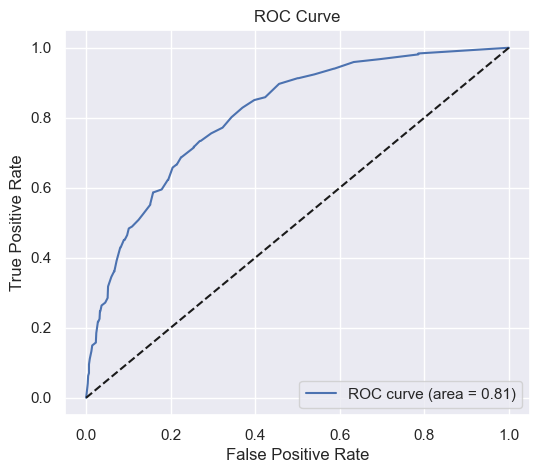


K Fold Cross Validation: 
Mean: 0.7972953907007797
Standard Deviation: 0.015309281278275978


In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import cross_val_score  

classifier = RandomForestClassifier(n_estimators = 50, criterion = 'entropy', random_state = 0)
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

"""classification_report generates a detailed table of precision, recall, F1-score, and support for each class in classification models.
Primary Uses
It evaluates per-class performance (not just overall accuracy), revealing imbalances—e.g., poor recall on minority class in churn prediction.
Ideal alongside confusion matrix for binary/multiclass tasks."""

print("\nclassification_report: ")
print('\n', classification_report(y_test, y_pred))

"""Confusion matrix evaluates classification models by showing actual vs predicted labels in a table format.
Primary Uses
It breaks down predictions into TP (true positive), TN, FP, FN—foundation for metrics like accuracy, precision, recall, F1.
Great for imbalanced data (e.g., churn) to spot class-specific errors beyond simple accuracy."""

print("\nconfusion_matrix_report: ")
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

"""accuracy_score computes the fraction of correct predictions in classification tasks.
Primary Use
It measures overall correctness: (correct predictions) / (total predictions), ideal for balanced datasets."""

print("\naccuracy_score: ")
print('\n', accuracy_score(y_test, y_pred))


"""roc_auc_score is used for
roc_auc_score computes the Area Under the ROC Curve (AUC) score—a single number summarizing binary classifier performance.
Primary Use
Evaluates how well predicted probabilities rank positive vs negative classes (0.5=random, 1.0=perfect). 
Robust for imbalanced data like churn prediction."""

print("\nroc_auc_score: ")
print('\n', roc_auc_score(y_test, y_pred))

"""ROC-AUC evaluates binary classification models by measuring 
their ability to distinguish between positive and negative classes across all thresholds."""

print("\nROC Curve computation and plot: ")
y_prob = classifier.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds  = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


""" K-Fold Cross Validation assesses model performance reliably by splitting data into K folds, training 
on K-1 and testing on one—repeating K times for averaged, unbiased estimates.
Primary Uses
Prevents overfitting by evaluating on unseen data multiple times.
Maximizes limited data usage (every sample trains/tests).
Provides stable mean/std dev scores to detect under/overfitting.
"""
print("\nK Fold Cross Validation: ")
accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv = 10, n_jobs = -1)
print(f'Mean: {accuracies.mean()}')
print(f'Standard Deviation: {accuracies.std()}')

# XGBClassifier model


classification_report: 

               precision    recall  f1-score   support

         0.0       0.84      0.88      0.85      1041
         1.0       0.59      0.51      0.55       368

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409


confusion_matrix_report: 
[[911 130]
 [179 189]]


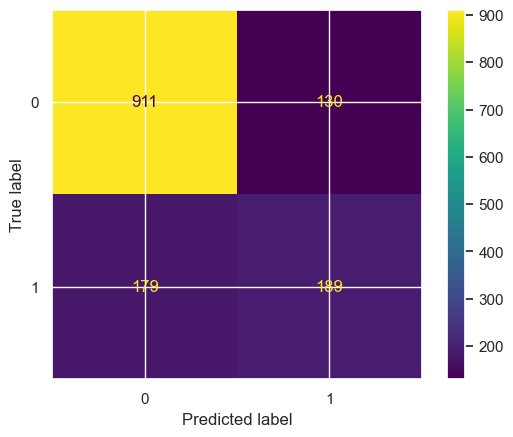


accuracy_score: 

 0.7806955287437899

roc_auc_score: 

 0.6943535166854614

ROC Curve computation and plot: 


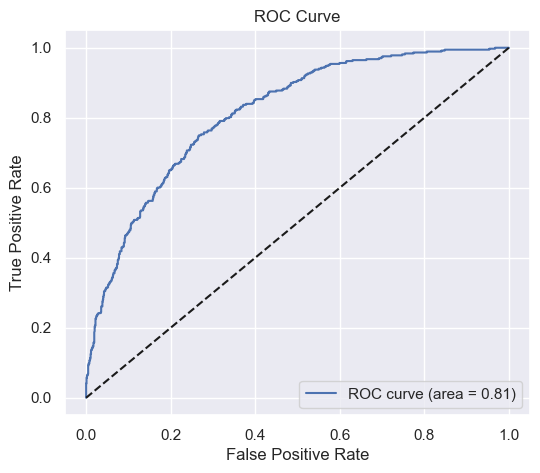


K Fold Cross Validation: 
Mean: 0.786821170779638
Standard Deviation: 0.013912640549980943


In [34]:
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, roc_auc_score, roc_curve, auc
from sklearn.model_selection import cross_val_score  

classifier = XGBClassifier()
classifier.fit(x_train, y_train)
y_pred = classifier.predict(x_test)

"""classification_report generates a detailed table of precision, recall, F1-score, and support for each class in classification models.
Primary Uses
It evaluates per-class performance (not just overall accuracy), revealing imbalances—e.g., poor recall on minority class in churn prediction.
Ideal alongside confusion matrix for binary/multiclass tasks."""

print("\nclassification_report: ")
print('\n', classification_report(y_test, y_pred))



"""Confusion matrix evaluates classification models by showing actual vs predicted labels in a table format.
Primary Uses
It breaks down predictions into TP (true positive), TN, FP, FN—foundation for metrics like accuracy, precision, recall, F1.
Great for imbalanced data (e.g., churn) to spot class-specific errors beyond simple accuracy."""

print("\nconfusion_matrix_report: ")
cm = confusion_matrix(y_test, y_pred)
print(cm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classifier.classes_)
disp.plot()
plt.show()

"""accuracy_score computes the fraction of correct predictions in classification tasks.
Primary Use
It measures overall correctness: (correct predictions) / (total predictions), ideal for balanced datasets."""

print("\naccuracy_score: ")
print('\n', accuracy_score(y_test, y_pred))


"""roc_auc_score is used for
roc_auc_score computes the Area Under the ROC Curve (AUC) score—a single number summarizing binary classifier performance.
Primary Use
Evaluates how well predicted probabilities rank positive vs negative classes (0.5=random, 1.0=perfect). 
Robust for imbalanced data like churn prediction."""

print("\nroc_auc_score: ")
print('\n', roc_auc_score(y_test, y_pred))

"""ROC-AUC evaluates binary classification models by measuring 
their ability to distinguish between positive and negative classes across all thresholds."""

print("\nROC Curve computation and plot: ")
y_prob = classifier.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds  = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


""" K-Fold Cross Validation assesses model performance reliably by splitting data into K folds, training 
on K-1 and testing on one—repeating K times for averaged, unbiased estimates.
Primary Uses
Prevents overfitting by evaluating on unseen data multiple times.
Maximizes limited data usage (every sample trains/tests).
Provides stable mean/std dev scores to detect under/overfitting.
"""
print("\nK Fold Cross Validation: ")
accuracies = cross_val_score(estimator = classifier, X = x_train, y = y_train, cv = 10, n_jobs = -1)
print(f'Mean: {accuracies.mean()}')
print(f'Standard Deviation: {accuracies.std()}')